In [9]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

############
# parameters
############

N_arr = np.arange(2, 62, 2)
nmax = 100
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, (2*np.pi), 0.1)

######################
# collective operators
######################

def collective_ops(N):
    sp, sm, I = qt.sigmap(), qt.sigmam(), qt.qeye(2)
    Sp = qt.jmat(N/2,'+')
    Sm = Sp.dag()
    Sz = qt.jmat(N/2,'z')
    HB = Sz+N/2*qt.qeye(N+1)
    return Sp, Sm, HB

############################
# Tavis-Cummings Hamiltonian
############################

def tavis_cummings(N, nmax, ω, ω0, g):
    a = qt.destroy(nmax)
    Sp, Sm, HB = collective_ops(N)
    IB = qt.qeye(N+1)
    H = ω * qt.tensor(a.dag()*a, IB) + ω0 * qt.tensor(qt.qeye(nmax), HB) + g * (qt.tensor(a, Sp) + qt.tensor(a.dag(), Sm))

    return H, HB

################
# Passive state
################

def passive_state(rho, H):
    r_val, r_vec = rho.eigenstates()
    idx = np.argsort(r_val)[::-1]          # decending order
    r_val = r_val[idx]

    e_val, e_vec = H.eigenstates()          # ascending order

    return sum(r_val[i] * e_vec[i] * e_vec[i].dag()
               for i in range(len(r_val)))

    
########################
# ergotropy calculation
########################

def ergotropy(ρ, H):
    ρ_p = passive_state(ρ, H)
    return qt.expect(H, ρ) - qt.expect(H, ρ_p)


################
# Initial state
################

def initial_state(N, nmax, state):
    if state=="coherent":
        psiA = qt.coherent(nmax, np.sqrt(N))
    elif state=="fock":
        psiA = qt.basis(nmax, N)
    psiB = qt.basis(N+1, 0)  
    return qt.tensor(psiA, psiB)


##############
# Pnm matrix
##############

def pnm_matrix(rho, H):
    r_val, r_vec = rho.eigenstates()
    idx = np.argsort(r_val)[::-1]
    r_val = r_val[idx]
    r_vec = [r_vec[i] for i in idx]

    e_val, e_vec = H.eigenstates()

    dim = len(e_val)
    pnm = np.zeros((dim, dim))

    for m in range(dim):
        for n in range(dim):
            pnm[n, m] = abs(e_vec[n].overlap(r_vec[m]))**2

    return pnm, r_val, e_val
    

############################
# ergotropy using pnm matrix
############################

def ergotropy_pnm(pnm, r_val, e_val):
    deltaE = e_val[:,None] - e_val[None,:]
    return np.sum(r_val[None,:] * pnm * deltaE)


############################
# variance using pnm matrix
############################

def variance_pnm(pnm, r_val, e_val):
    deltaE2 = (e_val[:,None] - e_val[None,:])**2
    mean2 = np.sum(r_val[None,:] * pnm * deltaE2)
    mean = ergotropy_pnm(pnm, r_val, e_val)
    return mean2 - mean**2


N= 2, τ=0.010, E_B=2.000
N= 4, τ=0.010, E_B=4.000
N= 6, τ=0.010, E_B=6.000
N= 8, τ=0.010, E_B=8.000
N=10, τ=0.010, E_B=10.000
N=12, τ=0.010, E_B=12.000
N=14, τ=0.010, E_B=14.000
N=16, τ=0.010, E_B=16.000
N=18, τ=0.010, E_B=18.000
N=20, τ=0.010, E_B=20.000
N=22, τ=0.010, E_B=22.000
N=24, τ=0.010, E_B=24.000
N=26, τ=0.010, E_B=26.000
N=28, τ=0.010, E_B=28.000
N=30, τ=0.010, E_B=30.000
N=32, τ=0.010, E_B=32.000
N=34, τ=0.010, E_B=34.000
N=36, τ=0.010, E_B=36.000
N=38, τ=0.010, E_B=38.000
N=40, τ=0.010, E_B=40.000
N=42, τ=0.010, E_B=42.000
N=44, τ=0.010, E_B=44.000
N=46, τ=0.010, E_B=46.000
N=48, τ=0.010, E_B=48.000
N=50, τ=0.010, E_B=50.000
N=52, τ=0.010, E_B=52.000
N=54, τ=0.010, E_B=54.000
N=56, τ=0.010, E_B=56.000
N=58, τ=0.010, E_B=58.000
N=60, τ=0.010, E_B=60.000


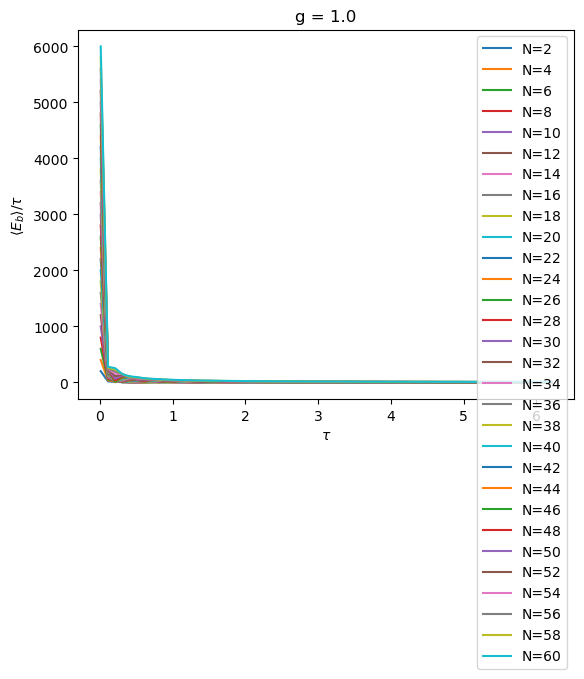

In [10]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

N_arr = np.arange(2, 62, 2)
nmax = 100
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, (2*np.pi), 0.1)

##############################################
# Plot Battery energy <Eb> as function of time 
# and pick time τ for which <Eb> is maximum
##############################################
τ_list = []

for N in N_arr:

    H, HB = tavis_cummings(N, nmax, ω, ω0, g)

    HB_full = qt.tensor(qt.qeye(nmax), HB)

    # Initial state
    ψ0 = initial_state(N, nmax, "coherent")

    # Time evolution
    result = qt.sesolve(H, ψ0, tlist, e_ops=HB_full)

    # Battery energy vs time
    Eb_list = np.array(result.expect[0])

    # Maximize charging power (Eb / t)
    power = Eb_list / tlist
    
    idx = np.argmax(power)
    
    τ = tlist[idx]
    
    τ_list.append(τ)

    print(f"N={N:2d}, τ={tlist[idx]:.3f}, E_B={Eb_list[idx]:.3f}")
    
    ##################################
    # Plot of battery energy with time
    ##################################
    
    plt.plot(tlist, power, label=f"N={N}")

plt.xlabel(r"$\tau$")
plt.ylabel(r"$\langle E_b \rangle / \tau$")
plt.legend()
plt.title(f"g = {g}")
plt.show()

N= 2, τ=0.010, Eb=1.999400, Ergotropy=1.999200, erg/Eb=0.999899983348 Variance=1.1996264101e-03
N= 4, τ=0.010, Eb=3.998000, Ergotropy=3.997600, erg/Eb=0.999899969986 Variance=3.1992521054e-03
N= 6, τ=0.010, Eb=5.995800, Ergotropy=5.995201, erg/Eb=0.999899956617 Variance=5.9993557619e-03
N= 8, τ=0.010, Eb=7.992801, Ergotropy=7.992001, erg/Eb=0.999899943244 Variance=9.6004150456e-03
N=10, τ=0.010, Eb=9.989001, Ergotropy=9.988001, erg/Eb=0.999899929872 Variance=1.4002906662e-02
N=12, τ=0.010, Eb=11.984402, Ergotropy=11.983202, erg/Eb=0.999899916507 Variance=1.9207305932e-02
N=14, τ=0.010, Eb=13.979002, Ergotropy=13.977603, erg/Eb=0.999899903158 Variance=2.5214086892e-02
N=16, τ=0.010, Eb=15.972803, Ergotropy=15.971204, erg/Eb=0.999899889795 Variance=3.2023727520e-02
N=18, τ=0.010, Eb=17.965803, Ergotropy=17.964005, erg/Eb=0.999899876413 Variance=3.9636704481e-02
N=20, τ=0.010, Eb=19.958004, Ergotropy=19.956006, erg/Eb=0.999899863023 Variance=4.8053487674e-02
N=22, τ=0.010, Eb=21.949405, E

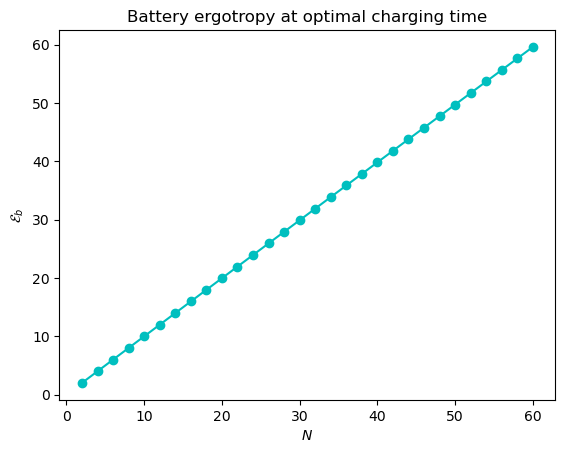

In [11]:
Eb_list = []
erg_list = []
var_list = []
ratio_list = []

for i, N in enumerate(N_arr):

    τ = τ_list[i]

    # Rebuild Hamiltonian
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)

    # Initial state
    ψ0 = initial_state(N, nmax, "coherent")

    # Evolve until τ
    result = qt.sesolve(H, ψ0, [0, τ])

    # Full density matrix at τ
    ρ_full = result.states[-1].proj()

    # Partial trace over cavity (subsystem 0)
    ρb = ρ_full.ptrace(1)

    Eb = qt.expect(HB, ρb)
    
    pnm, r_val, e_val = pnm_matrix(ρb, HB)

    # Ergotropy via pnm matrix
    erg = ergotropy_pnm(pnm, r_val, e_val)

    # Variance via pnm matrix
    var = variance_pnm(pnm, r_val, e_val)

    ratio = erg/Eb

    print(f"N={N:2d}, τ={τ:.3f}, Eb={Eb:.6f}, Ergotropy={erg:.6f}, erg/Eb={ratio:.12f} Variance={var:.10e}")

    Eb_list.append(Eb)
    erg_list.append(erg)
    var_list.append(var)
    ratio_list.append(ratio)

Eb_arr = np.array(Eb_list)
erg_arr = np.array(erg_list)
var_arr = np.array(var_list)

rel_fluct = np.sqrt(var_arr) / erg_arr

rel_fluc = np.sqrt(var_arr) / Eb_arr

###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.figure()
plt.plot(N_arr, erg_list, 'o-', color='c')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
plt.show()

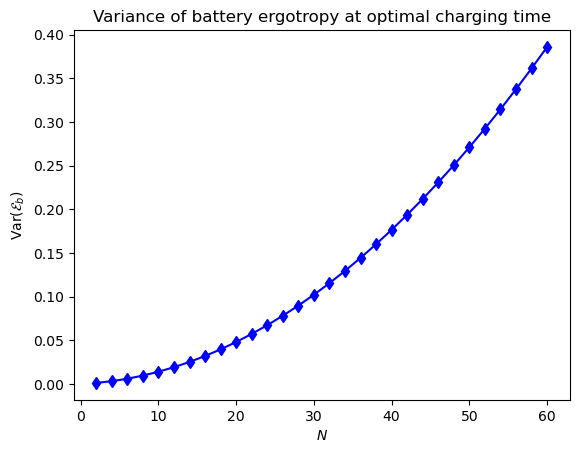

In [12]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, var_list, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
plt.show()

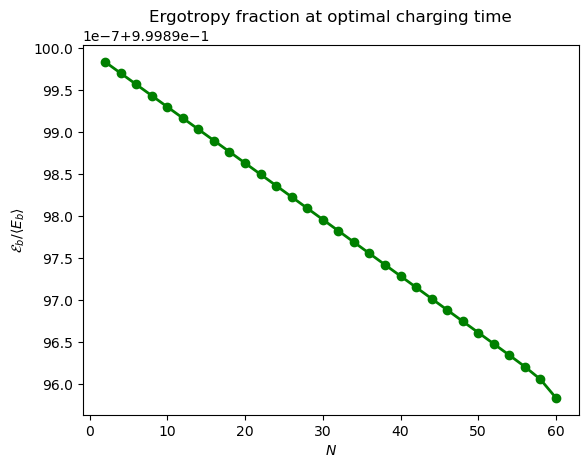

In [13]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
#############################################################


plt.figure()
plt.plot(N_arr, ratio_list, 'o-', color='g', linewidth=2)
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.title("Ergotropy fraction at optimal charging time")
plt.show()

N= 2, τ=0.010, Relative Fluctuation =0.017324740915, Relative Fluctuation with Eb =0.017323008153
N= 4, τ=0.010, Relative Fluctuation =0.014148971338, Relative Fluctuation with Eb =0.014147556016
N= 6, τ=0.010, Relative Fluctuation =0.012919585843, Relative Fluctuation with Eb =0.012918293324
N= 8, τ=0.010, Relative Fluctuation =0.012259971967, Relative Fluctuation with Eb =0.012258745274
N=10, τ=0.010, Relative Fluctuation =0.011847603181, Relative Fluctuation with Eb =0.011846417590
N=12, τ=0.010, Relative Fluctuation =0.011565391639, Relative Fluctuation with Eb =0.011564234134
N=14, τ=0.010, Relative Fluctuation =0.011360277172, Relative Fluctuation with Eb =0.011359140044
N=16, τ=0.010, Relative Fluctuation =0.011204649975, Relative Fluctuation with Eb =0.011203528275
N=18, τ=0.010, Relative Fluctuation =0.011082700898, Relative Fluctuation with Eb =0.011081591259
N=20, τ=0.010, Relative Fluctuation =0.010984716163, Relative Fluctuation with Eb =0.010983616186
N=22, τ=0.010, Relat

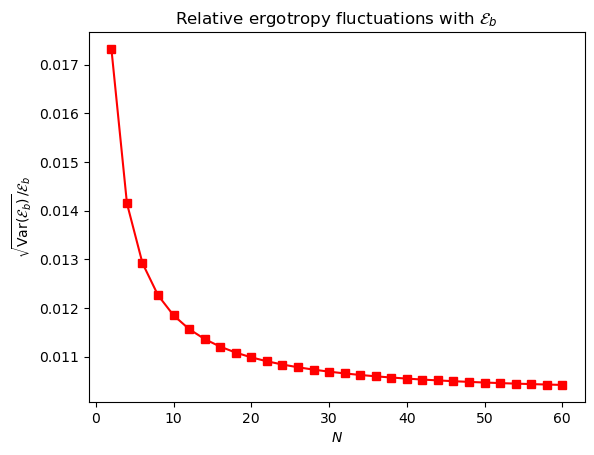

In [14]:
for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.3f}, Relative Fluctuation ={rel_fluct[idx]:.12f}, Relative Fluctuation with Eb ={rel_fluc[idx]:.12f}")

#######################################################################
# Plot fluctuations w.r.t ergotropy as a function of g for different N 
#######################################################################

plt.figure()
plt.plot(N_arr, rel_fluct, 's-', color='r')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations with $\mathcal{E}_b$")
plt.show()

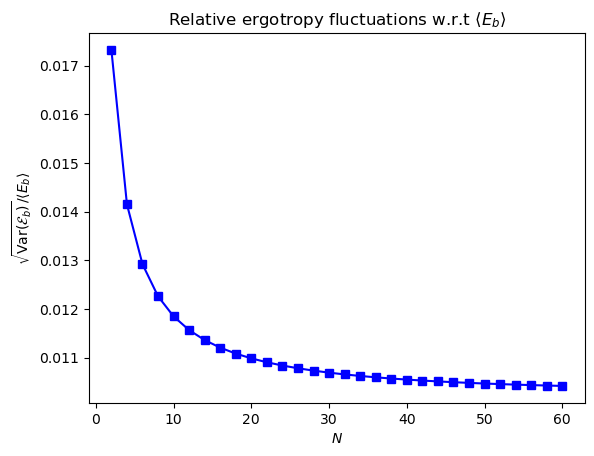

In [15]:
############################################################################
# Plot fluctuations w.r.t battery energy as a function of g for different N 
############################################################################

plt.figure()
plt.plot(N_arr, rel_fluc, 's-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
plt.show()